# Sakila SQL Analysis

This notebook analyzes the Sakila SQLite database using SQL and Python.

The goal is to extract KPIs, identify business insights, and support a final presentation.

## Setup

Load Python libraries, locate the project root, and connect to the local SQLite database.

In [6]:
from pathlib import Path
import sqlite3
import subprocess
import sys

import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch

import pandas as pd
import matplotlib.pyplot as plt

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = ROOT_DIR / "data" / "sakila.db"
QUERIES_DIR = ROOT_DIR / "queries"

if not DB_PATH.exists():
    download_script = ROOT_DIR / "scripts" / "download_db.py"
    subprocess.run([sys.executable, str(download_script)], check=True)

conn = sqlite3.connect(DB_PATH)
DB_PATH

PosixPath('/Users/antoniohopee/Desktop/projects/sakila-sql-analysis/data/sakila.db')

In [7]:
def run_query(sql: str) -> pd.DataFrame:
    return pd.read_sql_query(sql, conn)


def run_query_file(filename: str) -> pd.DataFrame:
    query_path = QUERIES_DIR / filename
    return run_query(query_path.read_text())

In [8]:
TEAL = "#18b7a6"
TEXT_COLOR = "#061832"
GRID_COLOR = "#c9c9c9"
BORDER_COLOR = "#e1e4ea"


def format_euro(value: float) -> str:
    return f"EUR {value:,.0f}".replace(",", ".")


def format_number(value: float) -> str:
    if abs(value) >= 1000:
        return f"{value:,.0f}".replace(",", ".")
    return f"{value:.1f}".rstrip("0").rstrip(".")


def create_chart_card(title: str, figsize=(12, 7), horizontal=False):
    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor("white")

    card = FancyBboxPatch(
        (0.03, 0.05),
        0.94,
        0.88,
        boxstyle="round,pad=0.02,rounding_size=0.07",
        transform=fig.transFigure,
        facecolor="white",
        edgecolor=BORDER_COLOR,
        linewidth=1.5,
        zorder=0,
    )
    fig.add_artist(card)
    fig.text(0.07, 0.86, title, fontsize=20, fontweight="bold", color=TEXT_COLOR)

    left = 0.23 if horizontal else 0.13
    ax = fig.add_axes([left, 0.17, 0.90 - left, 0.62], zorder=1)
    ax.set_facecolor("white")
    ax.grid(axis="x" if horizontal else "y", color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#9a9a9a")
    ax.tick_params(axis="both", length=0, labelsize=11)
    return fig, ax


def add_value_labels(ax, bars, currency=False, horizontal=False):
    if horizontal:
        max_width = max(bar.get_width() for bar in bars) if bars else 0
        offset = max_width * 0.015
        for bar in bars:
            value = bar.get_width()
            label = format_euro(value) if currency else format_number(value)
            ax.text(
                value + offset,
                bar.get_y() + bar.get_height() / 2,
                label,
                va="center",
                ha="left",
                fontsize=10,
                color="black",
            )
    else:
        max_height = max(bar.get_height() for bar in bars) if bars else 0
        offset = max_height * 0.02
        for bar in bars:
            value = bar.get_height()
            label = format_euro(value) if currency else format_number(value)
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + offset,
                label,
                va="bottom",
                ha="center",
                fontsize=10,
                color="black",
            )


def plot_vertical_bars(data, x, y, title, currency=False, figsize=(12, 7)):
    fig, ax = create_chart_card(title, figsize=figsize)
    bars = ax.bar(data[x], data[y], color=TEAL, width=0.5)
    add_value_labels(ax, bars, currency=currency)
    if currency:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: format_euro(value)))
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation=0)
    plt.show()


def plot_horizontal_bars(data, x, y, title, currency=False, figsize=(12, 7)):
    chart_data = data.sort_values(y, ascending=True)
    fig, ax = create_chart_card(title, figsize=figsize, horizontal=True)
    bars = ax.barh(chart_data[x], chart_data[y], color=TEAL, height=0.58)
    add_value_labels(ax, bars, currency=currency, horizontal=True)
    if currency:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: format_euro(value)))
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.show()


def plot_line(data, x, y, title, currency=False, figsize=(12, 7)):
    fig, ax = create_chart_card(title, figsize=figsize)
    ax.plot(data[x], data[y], color=TEAL, linewidth=3, marker="s", markersize=11)
    if currency:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: format_euro(value)))
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation=0)
    plt.show()


def plot_kpi_cards(data):
    row = data.iloc[0]
    metrics = [
        ("Fatturato", format_euro(row["total_revenue"])),
        ("Pagamenti", format_number(row["total_payments"])),
        ("Clienti unici", format_number(row["unique_customers"])),
        ("Ticket medio", f"EUR {row['avg_payment']:.2f}"),
    ]

    fig = plt.figure(figsize=(12, 5))
    fig.patch.set_facecolor("white")
    card = FancyBboxPatch(
        (0.03, 0.08),
        0.94,
        0.82,
        boxstyle="round,pad=0.02,rounding_size=0.07",
        transform=fig.transFigure,
        facecolor="white",
        edgecolor=BORDER_COLOR,
        linewidth=1.5,
    )
    fig.add_artist(card)
    fig.text(0.07, 0.80, "KPI principali", fontsize=20, fontweight="bold", color=TEXT_COLOR)

    for index, (label, value) in enumerate(metrics):
        x = 0.09 + index * 0.22
        metric_box = FancyBboxPatch(
            (x, 0.27),
            0.18,
            0.32,
            boxstyle="round,pad=0.02,rounding_size=0.03",
            transform=fig.transFigure,
            facecolor=TEAL,
            edgecolor=TEAL,
        )
        fig.add_artist(metric_box)
        fig.text(x + 0.09, 0.45, value, ha="center", va="center", fontsize=18, fontweight="bold", color="white")
        fig.text(x + 0.09, 0.34, label, ha="center", va="center", fontsize=11, color="white")

    plt.show()


## Database Overview

Sakila models a DVD rental business. The core operational flow is customer -> rental -> inventory -> film, with payments tied to rentals and staff. Geography is modeled through customer addresses, cities, and countries.

In [9]:
tables = run_query("""
SELECT name, type
FROM sqlite_master
WHERE type IN ('table', 'view')
  AND name NOT LIKE 'sqlite_%'
ORDER BY type, name;
""")
tables

,name,type
0,actor,table
1,address,table
2,category,table
3,city,table
4,country,table
5,customer,table
6,film,table
7,film_actor,table
8,film_category,table
9,film_text,table


In [10]:
table_counts = run_query("""
SELECT 'actor' AS table_name, COUNT(*) AS rows FROM actor
UNION ALL SELECT 'customer', COUNT(*) FROM customer
UNION ALL SELECT 'film', COUNT(*) FROM film
UNION ALL SELECT 'inventory', COUNT(*) FROM inventory
UNION ALL SELECT 'rental', COUNT(*) FROM rental
UNION ALL SELECT 'payment', COUNT(*) FROM payment
UNION ALL SELECT 'store', COUNT(*) FROM store
ORDER BY rows DESC;
""")
table_counts

,table_name,rows
0,payment,16049
1,rental,16044
2,inventory,4581
3,film,1000
4,customer,599
5,actor,200
6,store,2


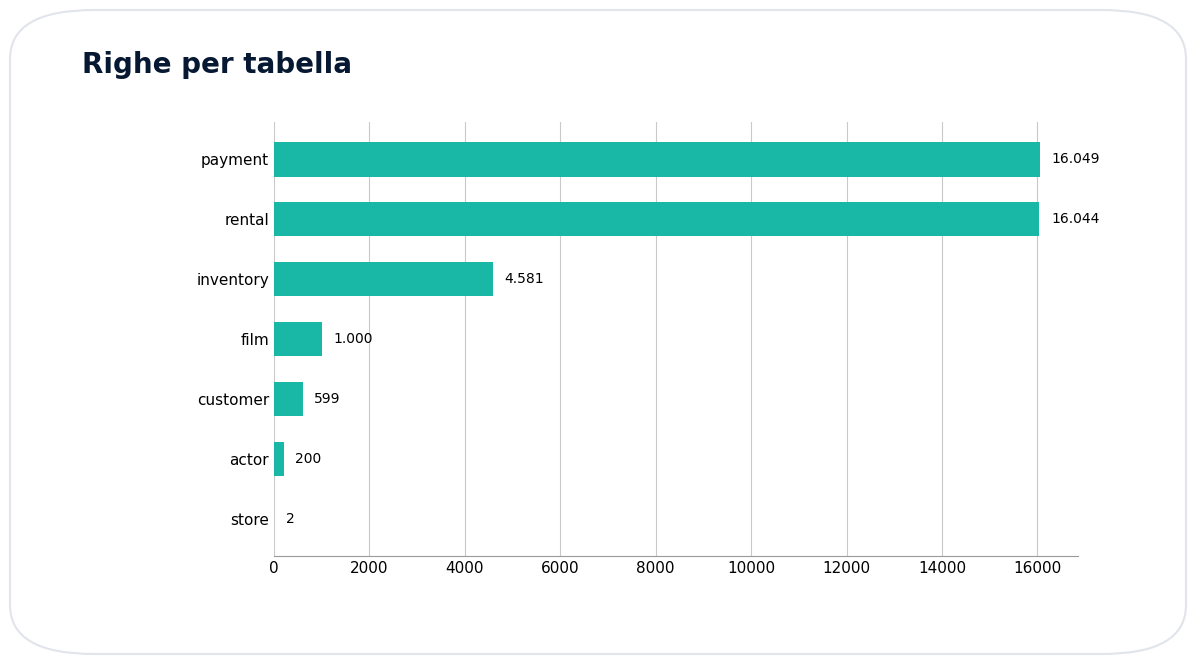

In [11]:
plot_horizontal_bars(table_counts, "table_name", "rows", "Righe per tabella")

### Key Relationships

- `payment.rental_id` links revenue to each rental.
- `rental.inventory_id` links each rental to a physical film copy.
- `inventory.film_id` links inventory copies to film titles.
- `film_category` and `film_actor` connect films to categories and actors.
- `customer.address_id -> address.city_id -> city.country_id` maps customers to countries.
- `store.manager_staff_id` identifies the store manager, while `staff.store_id` identifies staff assignment.

## Core KPIs

In [12]:
core_kpis = run_query_file("01_core_kpis.sql")
core_kpis

,total_revenue,total_payments,unique_customers,avg_payment
0,67416.51,16049,599,4.2


In [13]:
plot_kpi_cards(core_kpis)

<Figure size 1200x500 with 0 Axes>

## Monthly Revenue

In [14]:
monthly_revenue = run_query_file("02_monthly_revenue.sql")
monthly_revenue

,month,revenue,payments,unique_customers,avg_payment
0,2005-05,4824.43,1157,520,4.17
1,2005-06,9631.88,2312,590,4.17
2,2005-07,28373.89,6711,599,4.23
3,2005-08,24072.13,5687,599,4.23
4,2006-02,514.18,182,158,2.83


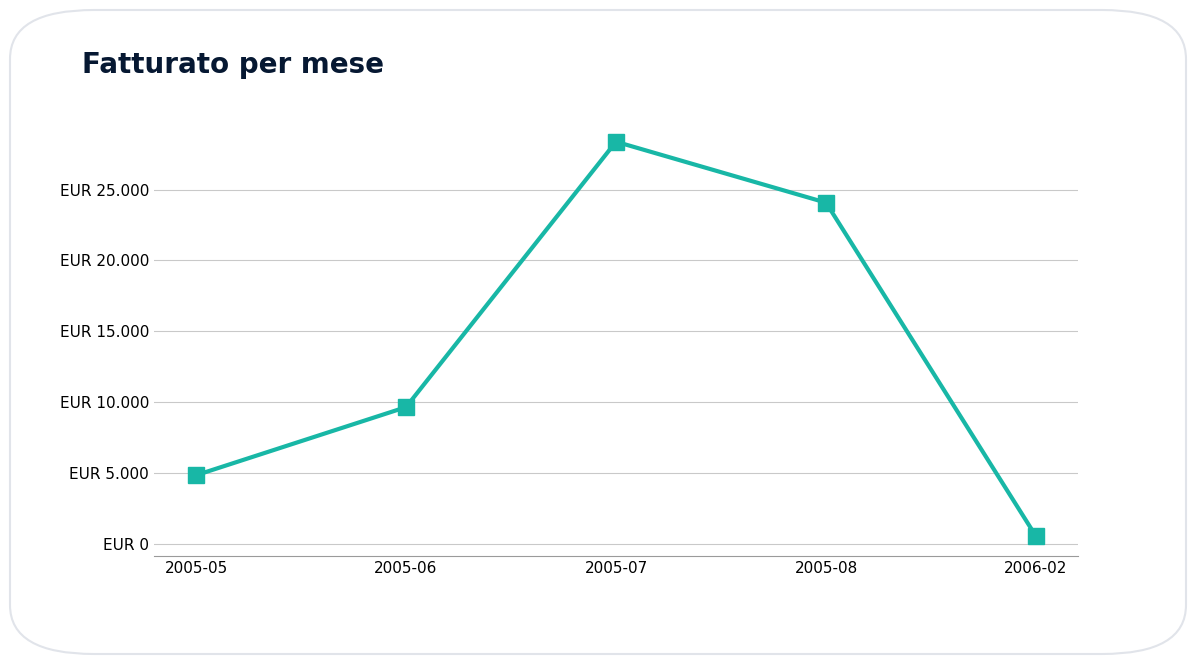

In [15]:
plot_line(monthly_revenue, "month", "revenue", "Fatturato per mese", currency=True)

## Top Films By Revenue

In [16]:
top_films = run_query_file("03_top_films_by_revenue.sql")
top_films

,film_id,film,revenue,rentals,inventory_copies
0,879,TELEGRAPH VOYAGE,231.73,27,7
1,973,WIFE TURN,223.69,31,8
2,1000,ZORRO ARK,214.69,31,8
3,369,GOODFELLAS SALUTE,209.69,31,8
4,764,SATURDAY LAMBS,204.72,28,8
5,893,TITANS JERK,201.71,29,8
6,897,TORQUE BOUND,198.72,27,8
7,403,HARRY IDAHO,195.70,30,8
8,460,INNOCENT USUAL,191.74,26,8
9,444,HUSTLER PARTY,190.78,22,8


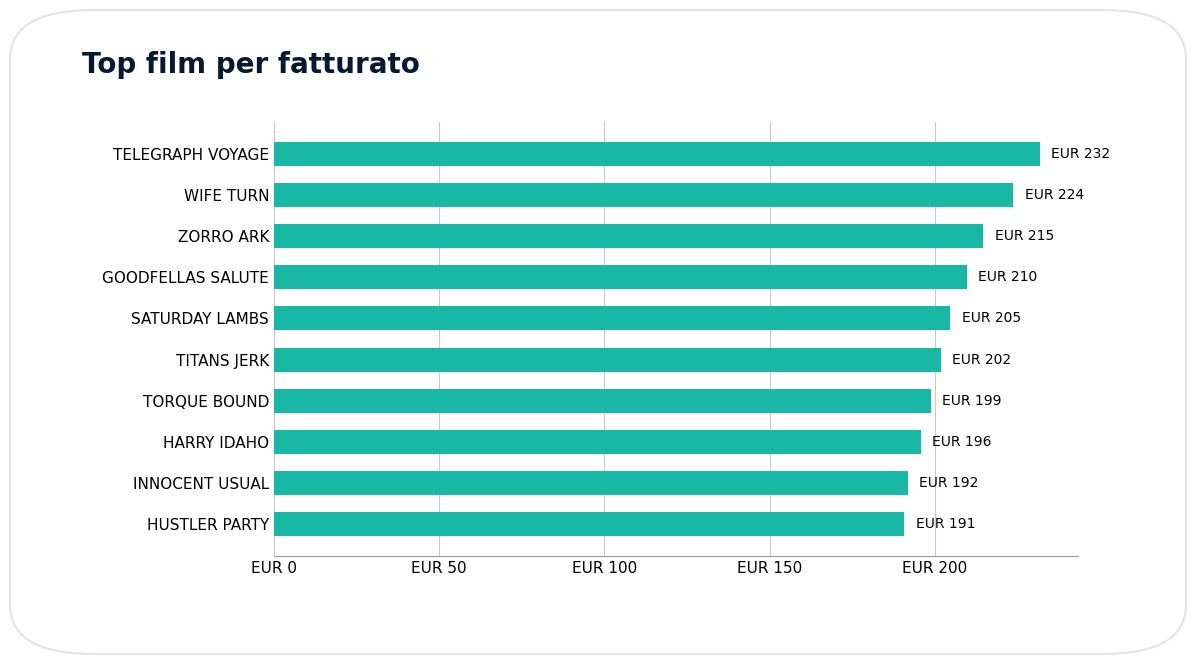

In [17]:
plot_horizontal_bars(top_films, "film", "revenue", "Top film per fatturato", currency=True)

## Top Countries By Revenue

In [18]:
top_countries = run_query_file("04_top_countries_by_revenue.sql")
top_countries

,country,rentals,revenue,unique_customers
0,India,1572,6628.28,60
1,China,1426,5798.74,53
2,United States,968,4110.32,36
3,Japan,825,3470.75,31
4,Mexico,796,3307.04,30
5,Brazil,748,3200.52,28
6,Russian Federation,713,3045.87,28
7,Philippines,568,2381.32,20
8,Turkey,388,1662.12,15
9,Nigeria,352,1511.48,13


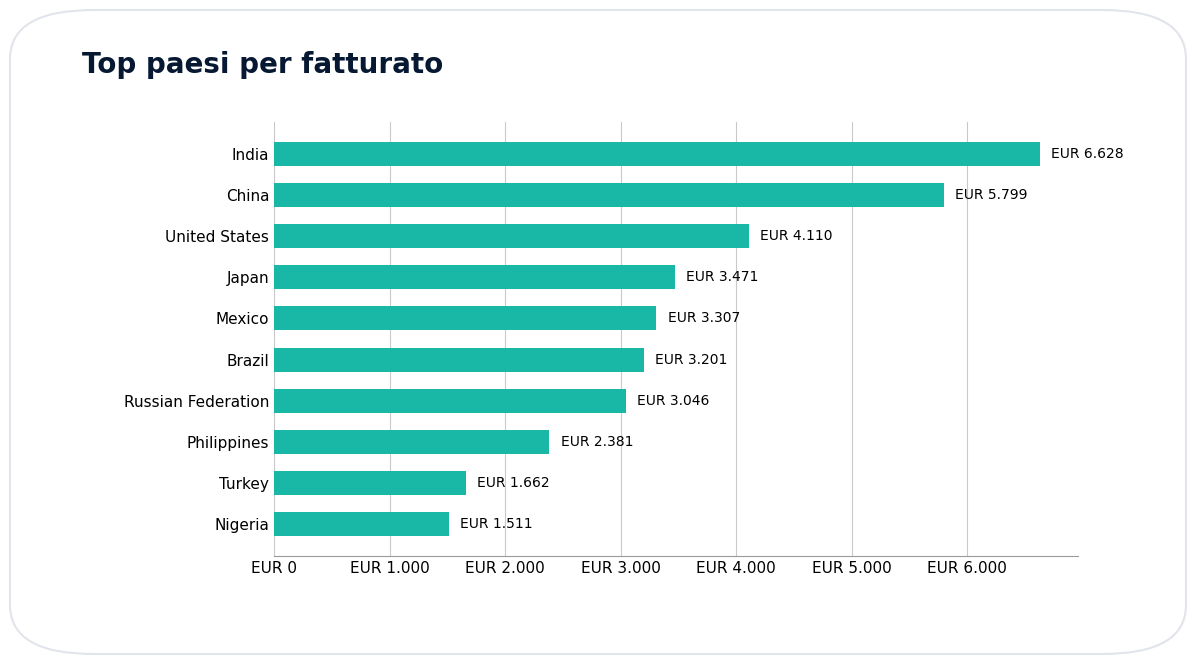

In [19]:
plot_horizontal_bars(top_countries, "country", "revenue", "Top paesi per fatturato", currency=True)

## Category Performance

In [20]:
top_categories = run_query_file("05_top_categories_world.sql")
top_categories

,category,rentals,revenue
0,Sports,1179,5314.21
1,Sci-Fi,1101,4756.98
2,Animation,1166,4656.30
3,Drama,1060,4587.39
4,Comedy,941,4383.58
5,Action,1112,4375.85
6,New,940,4351.62
7,Games,969,4281.33
8,Foreign,1033,4270.67
9,Family,1096,4226.07


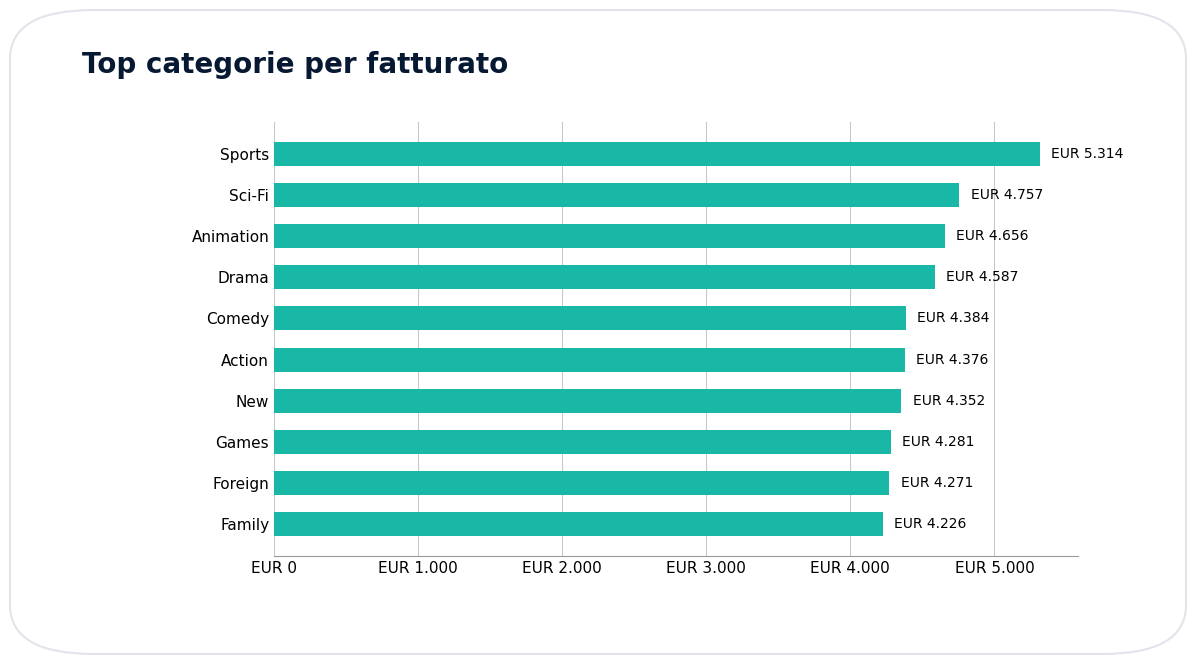

In [21]:
plot_horizontal_bars(top_categories.head(10), "category", "revenue", "Top categorie per fatturato", currency=True)

## Top Customers

In [22]:
top_customers = run_query_file("06_top_customers.sql")
top_customers

,customer_id,customer,active,store_id,rentals,amount_spent
0,526,KARL SEAL,1,2,45,221.55
1,148,ELEANOR HUNT,1,1,46,216.54
2,144,CLARA SHAW,1,1,42,195.58
3,137,RHONDA KENNEDY,1,2,39,194.61
4,178,MARION SNYDER,1,2,39,194.61
5,459,TOMMY COLLAZO,1,1,38,186.62
6,469,WESLEY BULL,1,2,40,177.60
7,468,TIM CARY,1,1,39,175.61
8,236,MARCIA DEAN,1,1,42,175.58
9,181,ANA BRADLEY,1,2,34,174.66


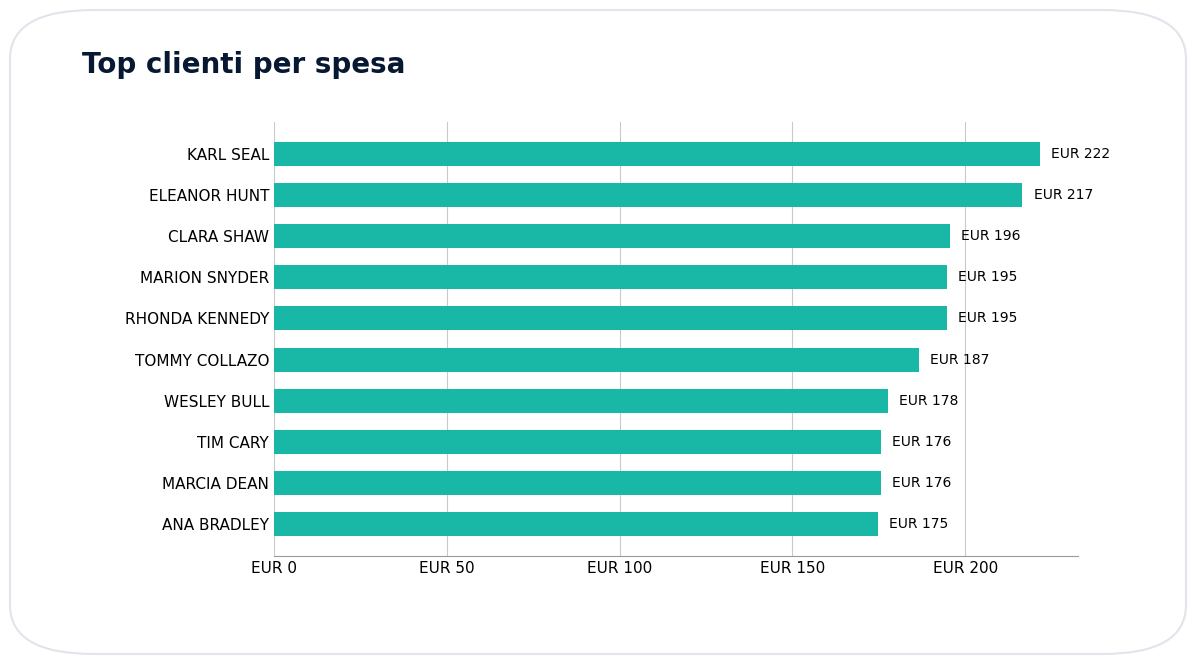

In [23]:
plot_horizontal_bars(top_customers, "customer", "amount_spent", "Top clienti per spesa", currency=True)

## Store Performance

In [24]:
store_performance = run_query_file("07_store_performance.sql")
store_performance

,store_id,store_location,manager,payments,revenue
0,2,"28 MySQL Boulevard, Woodridge, Australia",Jon Stephens,7992,33927.04
1,1,"47 MySakila Drive, Lethbridge, Canada",Mike Hillyer,8057,33489.47


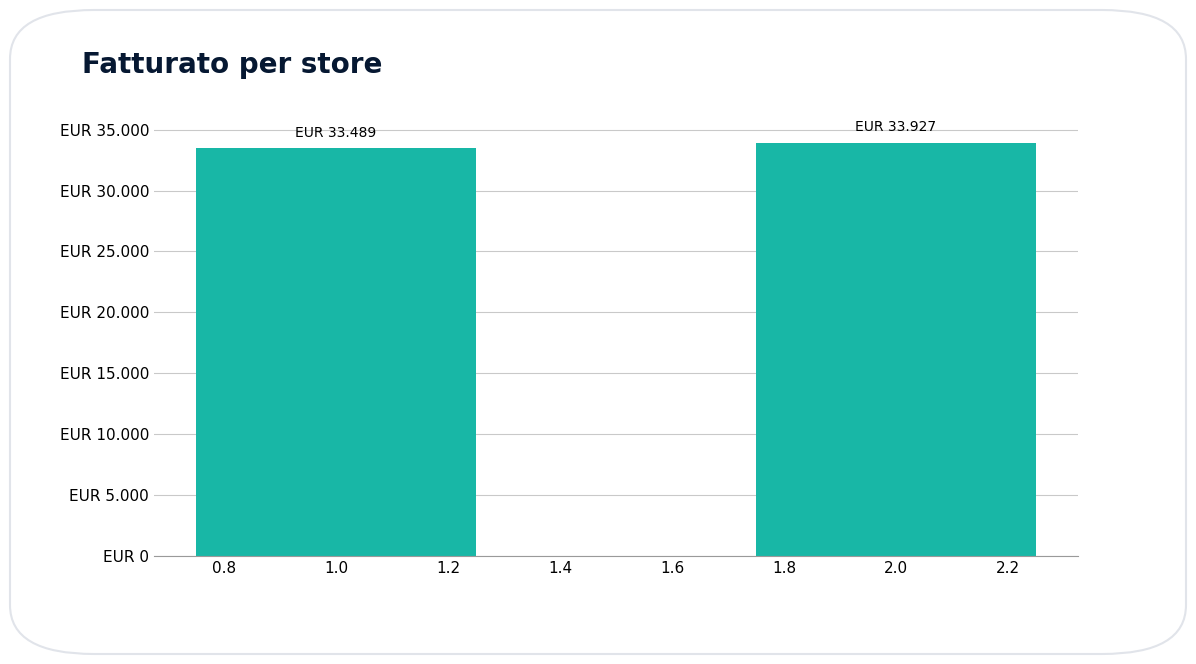

In [25]:
plot_vertical_bars(store_performance, "store_id", "revenue", "Fatturato per store", currency=True)

## Rating Distribution

In [26]:
rating_distribution = run_query_file("08_rating_distribution.sql")
rating_distribution

,rating,films,pct_films
0,PG-13,223,22.3
1,NC-17,210,21.0
2,R,195,19.5
3,PG,194,19.4
4,G,178,17.8


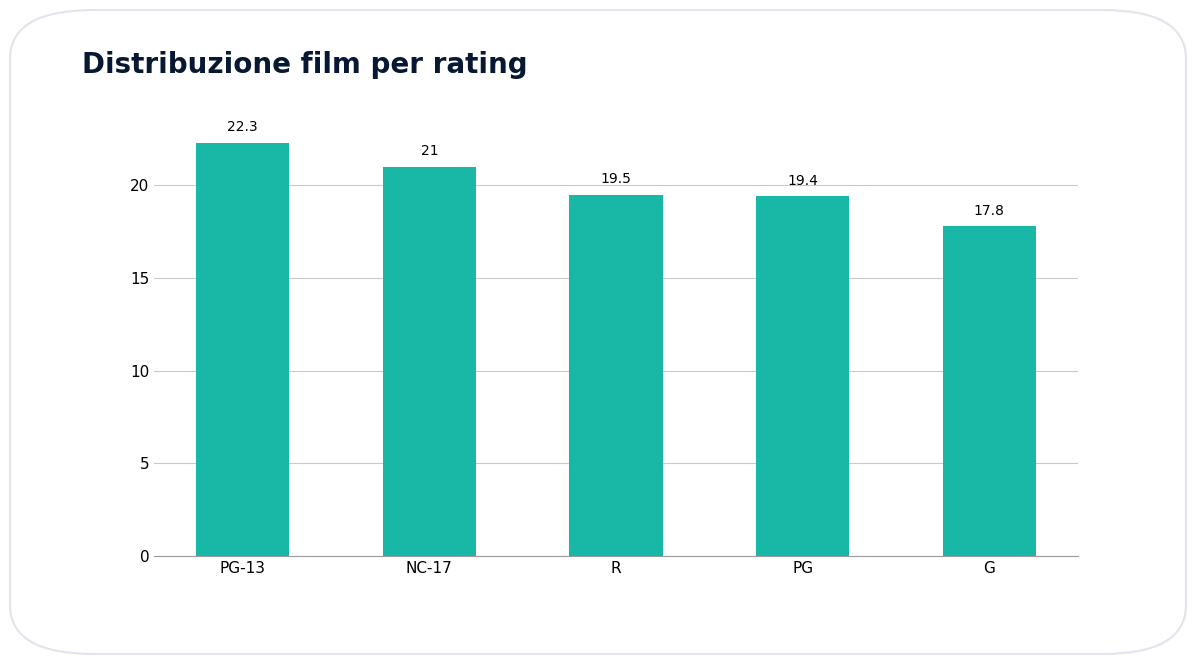

In [27]:
plot_vertical_bars(rating_distribution, "rating", "pct_films", "Distribuzione film per rating")

## Top 3 Genres Per Country

In [ ]:
top_3_genres_per_country = run_query_file("09_top_3_genres_per_country.sql")
top_3_genres_per_country.head(15)

In [ ]:
top_3_category_totals = (
    top_3_genres_per_country
    .groupby("category", as_index=False)["rentals"]
    .sum()
    .sort_values("rentals", ascending=False)
    .head(10)
)
plot_horizontal_bars(top_3_category_totals, "category", "rentals", "Categorie piu frequenti nelle top 3 nazionali")

## Top Genre Per Country

In [ ]:
top_genre_per_country = run_query_file("10_top_genre_per_country.sql")
top_genre_per_country.head(15)

In [ ]:
top_genre_counts = (
    top_genre_per_country
    .groupby("top_category", as_index=False)["country"]
    .count()
    .rename(columns={"country": "countries"})
    .sort_values("countries", ascending=False)
)
plot_horizontal_bars(top_genre_counts.head(10), "top_category", "countries", "Categorie leader per numero di paesi")

## Top Actors

In [ ]:
top_actors = run_query_file("11_top_actors.sql")
top_actors

In [ ]:
plot_horizontal_bars(top_actors, "actor", "rentals", "Top attori per noleggi")

## Film Length Performance

In [ ]:
film_length_performance = run_query_file("12_film_length_performance.sql")
film_length_performance

In [ ]:
plot_horizontal_bars(film_length_performance, "film", "rentals", "Film piu noleggiati e durata")

## Top Languages

In [ ]:
top_languages = run_query_file("13_top_languages.sql")
top_languages

In [ ]:
plot_vertical_bars(top_languages, "language", "revenue", "Fatturato per lingua", currency=True)

## Export Outputs

In [ ]:
OUTPUTS_DIR = ROOT_DIR / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

exports = {
    "core_kpis.csv": core_kpis,
    "monthly_revenue.csv": monthly_revenue,
    "top_films_by_revenue.csv": top_films,
    "top_countries_by_revenue.csv": top_countries,
    "top_categories_world.csv": top_categories,
    "top_customers.csv": top_customers,
    "store_performance.csv": store_performance,
    "rating_distribution.csv": rating_distribution,
    "top_3_genres_per_country.csv": top_3_genres_per_country,
    "top_genre_per_country.csv": top_genre_per_country,
    "top_actors.csv": top_actors,
    "film_length_performance.csv": film_length_performance,
    "top_languages.csv": top_languages,
}

for filename, dataframe in exports.items():
    dataframe.to_csv(OUTPUTS_DIR / filename, index=False)

sorted(exports)

## Initial Insights

- Total revenue is concentrated in the 2005 summer months, with July and August as the strongest periods.
- India, China, and the United States are the largest countries by revenue.
- Sports is the top category by revenue in the current dataset.
- Store revenue is very balanced across the two stores, with store 2 slightly ahead.

In [28]:
conn.close()